In [46]:
# Importaciones
import pandas as pd
import numpy as np
import re
import json
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import gensim.downloader as api
from gensim.models import KeyedVectors
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

SEMILLA: int = 42
torch.manual_seed(SEMILLA)
np.random.seed(SEMILLA)

PAPER_DIR: Path = Path('/home/jaime/Projects/maia/local/tdl/miniproyecto2/paper_template')

[nltk_data] Downloading package stopwords to /home/jaime/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/jaime/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/jaime/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [47]:
# Cargar datos
df = pd.read_csv('/home/jaime/Projects/maia/local/tdl/miniproyecto2/movie.csv')
print(f'Filas: {df.shape[0]}, Columnas: {df.shape[1]}')
df.head()

Filas: 40000, Columnas: 2


,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


In [48]:
# Muestra del conjunto de datos
df.sample(5, random_state=SEMILLA)

,text,label
32823,The central theme in this movie seems to be co...,0
16298,"An excellent example of ""cowboy noir"", as it's...",1
28505,The ending made my heart jump up into my throa...,0
6689,Only the chosen ones will appreciate the quali...,1
26893,"This is a really funny film, especially the se...",1


label
0    20019
1    19981
Name: count, dtype: int64


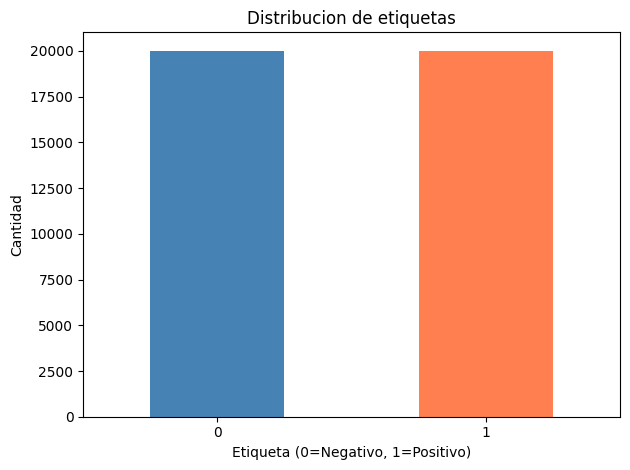

In [49]:
# Distribucion de etiquetas
distribucion: pd.Series = df['label'].value_counts().sort_index()
print(distribucion)
distribucion.plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Distribucion de etiquetas')
plt.xlabel('Etiqueta (0=Negativo, 1=Positivo)')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PAPER_DIR / 'distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

In [50]:
# Verificar filas imputables (nulos o texto vacio)
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nFilas con texto vacio: {(df["text"].str.strip() == "").sum()}')

df = df.dropna(subset=['text', 'label'])
df = df[df['text'].str.strip() != '']
df = df.reset_index(drop=True)
print(f'\nFilas tras limpieza: {len(df)}')

Valores nulos por columna:
text     0
label    0
dtype: int64

Filas con texto vacio: 0

Filas tras limpieza: 40000


## Pipeline de limpieza y tokenizacion

Cada resena pasa por los siguientes pasos:

1. **Eliminar HTML** -- etiquetas `<br />`, `<b>`, etc.
2. **Filtrar caracteres** -- solo letras A-Z; numeros y puntuacion se descartan.
3. **Minusculas** -- normalizacion de mayusculas.
4. **Stopwords** -- eliminacion de palabras sin carga semantica (ingles).
5. **Lematizacion** -- `WordNetLemmatizer` reduce cada token a su forma base.

### Ejemplo entrada vs salida

**Entrada (texto crudo):**
```
"A waste of film. Utter rubbish.<br /><br />Frakes should hand in his directors chair!"
```

**Salida (lista de tokens):**
```python
['waste', 'film', 'utter', 'rubbish', 'frake', 'hand', 'director', 'chair']
```

Los tokens se mapean a indices usando el vocabulario construido desde el conjunto de entrenamiento.
Las palabras presentes en GloVe se inicializan con sus vectores; las demas se inicializan en cero.

In [51]:
# Pipeline: limpieza, tokenizacion, stopwords, lematizacion
palabras_stop: set[str] = set(stopwords.words('english'))
lematizador: WordNetLemmatizer = WordNetLemmatizer()


def limpiar_texto(texto: str) -> list[str]:
    # type: (str) -> list[str]
    """Limpia y tokeniza: elimina HTML, filtra no-letras, quita stopwords y lematiza."""
    texto = re.sub(r'<[^>]+>', ' ', texto)
    texto = re.sub(r'[^a-zA-Z]', ' ', texto)
    texto = texto.lower()
    tokens: list[str] = texto.split()
    tokens = [lematizador.lemmatize(t) for t in tokens
              if t not in palabras_stop and len(t) > 1]
    return tokens


print('Procesando textos...')
df['tokens'] = df['text'].apply(limpiar_texto)

# Cargar vectores GloVe preentrenados (primera ejecucion descarga ~65 MB)
print('Cargando GloVe...')
glove: KeyedVectors = api.load('glove-wiki-gigaword-100')
VECTOR_SIZE: int = 100
print(f'GloVe cargado: {len(glove.key_to_index)} palabras, dimension {VECTOR_SIZE}')
print('Ejemplo entrada:', df['text'][0][:80], '...')
print('Ejemplo salida: ', df['tokens'][0][:10])

Procesando textos...
Cargando GloVe...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe cargado: 400000 palabras, dimension 100
Ejemplo entrada: I grew up (b. 1965) watching and loving the Thunderbirds. All my mates at school ...
Ejemplo salida:  ['grew', 'watching', 'loving', 'thunderbird', 'mate', 'school', 'watched', 'played', 'thunderbird', 'school']


In [52]:
# Dividir en entrenamiento (80%), validacion (10%) y prueba (10%)
X: np.ndarray = df['tokens'].values
y: np.ndarray = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=SEMILLA, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEMILLA, stratify=y_temp
)
print(f'Entrenamiento: {len(X_train)}')
print(f'Validacion:    {len(X_val)}')
print(f'Prueba:        {len(X_test)}')

Entrenamiento: 32000
Validacion:    4000
Prueba:        4000


In [53]:
# Vocabulario e indices basados en el conjunto de entrenamiento
MAX_LEN: int = 400
PAD_IDX: int = 0
UNK_IDX: int = 1

contador: Counter = Counter(t for tokens in X_train for t in tokens)
vocab: list[str] = [w for w, _ in contador.most_common()]
word2idx: dict[str, int] = {w: i + 2 for i, w in enumerate(vocab)}
VOCAB_SIZE: int = len(word2idx) + 2

# Matriz de embeddings inicializada con GloVe
embedding_matrix: np.ndarray = np.zeros((VOCAB_SIZE, VECTOR_SIZE))
cobertura: int = 0
for word, idx in word2idx.items():
    if word in glove.key_to_index:
        embedding_matrix[idx] = glove[word]
        cobertura += 1
print(f'Vocabulario: {VOCAB_SIZE} palabras')
print(f'Cobertura GloVe: {cobertura}/{len(word2idx)} ({100*cobertura/len(word2idx):.1f}%)')


def tokens_a_indices(tokens: list[str], max_len: int = MAX_LEN) -> list[int]:
    # type: (list[str], int) -> list[int]
    """Convierte tokens a indices enteros con padding hasta max_len."""
    indices: list[int] = [word2idx.get(t, UNK_IDX) for t in tokens[:max_len]]
    indices += [PAD_IDX] * (max_len - len(indices))
    return indices

Vocabulario: 74495 palabras
Cobertura GloVe: 57522/74493 (77.2%)


In [54]:
# Dataset y DataLoaders
class ComentariosDataset(Dataset):
    """Dataset de resenas con etiquetas de sentimiento."""

    def __init__(self, textos: np.ndarray, etiquetas: np.ndarray) -> None:
        # type: (np.ndarray, np.ndarray) -> None
        """Convierte tokens a tensores de indices y almacena etiquetas."""
        self.X: list[torch.Tensor] = [
            torch.tensor(tokens_a_indices(t), dtype=torch.long) for t in textos
        ]
        self.y: torch.Tensor = torch.tensor(etiquetas, dtype=torch.float32)

    def __len__(self) -> int:
        # type: () -> int
        # Numero de muestras
        return len(self.y)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        # type: (int) -> tuple[torch.Tensor, torch.Tensor]
        # Devuelve par (secuencia de indices, etiqueta)
        return self.X[idx], self.y[idx]


BATCH_SIZE: int = 64
train_ds: ComentariosDataset = ComentariosDataset(X_train, y_train)
val_ds:   ComentariosDataset = ComentariosDataset(X_val,   y_val)
test_ds:  ComentariosDataset = ComentariosDataset(X_test,  y_test)

train_loader: DataLoader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader:   DataLoader = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader:  DataLoader = DataLoader(test_ds,  batch_size=BATCH_SIZE)
print(f'Batches de entrenamiento: {len(train_loader)}')

Batches de entrenamiento: 500


In [55]:
# Modelo BiLSTM y clase de parada anticipada

class SentimentBiLSTM(nn.Module):
    """BiLSTM con mean pooling para clasificacion binaria de sentimiento."""

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        n_layers: int,
        dropout: float = 0.3,
    ) -> None:
        # type: (int, int, int, int, float) -> None
        """Inicializa capas: embedding, BiLSTM y densa de salida."""
        super().__init__()
        # Embedding inicializado con GloVe; se congela al inicio del entrenamiento
        self.embedding: nn.Embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=PAD_IDX
        )
        self.embedding.weight = nn.Parameter(
            torch.tensor(embedding_matrix, dtype=torch.float32)
        )
        # Capas BiLSTM apiladas con dropout entre capas
        self.lstm: nn.LSTM = nn.LSTM(
            embed_dim, hidden_dim, n_layers,
            batch_first=True, bidirectional=True, dropout=dropout
        )
        self.dropout_layer: nn.Dropout = nn.Dropout(dropout)
        # FC de salida; hidden_dim * 2 por bidireccionalidad
        self.fc: nn.Linear = nn.Linear(hidden_dim * 2, 1)
        self.sigmoid: nn.Sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # type: (torch.Tensor) -> torch.Tensor
        """Embedding, BiLSTM con mean pooling sobre estados ocultos, FC y sigmoid."""
        emb: torch.Tensor = self.dropout_layer(self.embedding(x))
        output, _ = self.lstm(emb)
        # Promedio de los estados ocultos de todas las posiciones de la secuencia
        pooled: torch.Tensor = output.mean(dim=1)
        salida: torch.Tensor = self.fc(self.dropout_layer(pooled))
        return self.sigmoid(salida).squeeze(1)


class EarlyStopping:
    """Detiene el entrenamiento cuando val_loss no mejora durante patience epocas."""

    def __init__(self, patience: int = 5, min_delta: float = 1e-4) -> None:
        # type: (int, float) -> None
        """Inicializa contador y umbral minimo de mejora."""
        self.patience: int = patience
        self.min_delta: float = min_delta
        self.counter: int = 0
        self.best_loss: float = float('inf')
        self.stop: bool = False

    def step(self, val_loss: float) -> None:
        # type: (float) -> None
        """Actualiza estado; activa self.stop si no hay mejora en patience epocas."""
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


HIDDEN_DIM: int = 256
N_LAYERS: int = 2
device: torch.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

modelo: SentimentBiLSTM = SentimentBiLSTM(
    VOCAB_SIZE, VECTOR_SIZE, HIDDEN_DIM, N_LAYERS
).to(device)
print(modelo)
total_params: int = sum(p.numel() for p in modelo.parameters())
print(f'Parametros totales: {total_params:,}')

Dispositivo: cpu
SentimentBiLSTM(
  (embedding): Embedding(74495, 100, padding_idx=0)
  (lstm): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout_layer): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Parametros totales: 9,760,157


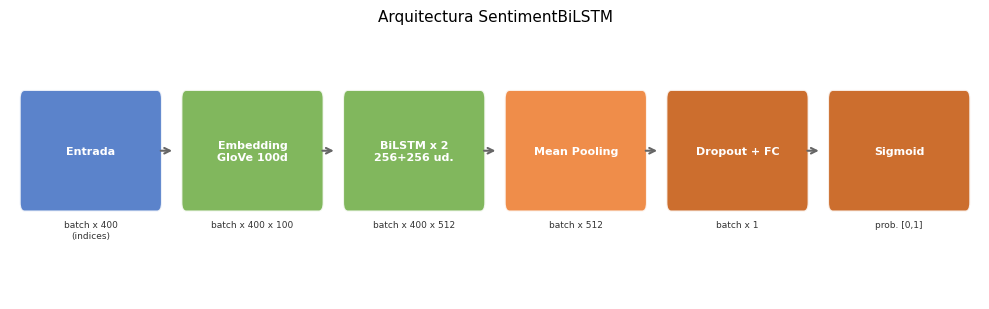

Figura guardada en /home/jaime/Projects/maia/local/tdl/miniproyecto2/paper_template/arquitectura_bilstm.png


In [56]:
# Visualizacion de la arquitectura del modelo

def dibujar_arquitectura() -> None:
    # type: () -> None
    """Genera y guarda diagrama de capas del modelo BiLSTM."""
    capas: list[tuple[str, str]] = [
        ('Entrada', 'batch x 400\n(indices)'),
        ('Embedding\nGloVe 100d', 'batch x 400 x 100'),
        ('BiLSTM x 2\n256+256 ud.', 'batch x 400 x 512'),
        ('Mean Pooling', 'batch x 512'),
        ('Dropout + FC', 'batch x 1'),
        ('Sigmoid', 'prob. [0,1]'),
    ]
    colores: list[str] = ['#4472C4', '#70AD47', '#70AD47', '#ED7D31', '#C55A11', '#C55A11']

    fig, ax = plt.subplots(figsize=(10, 3.2))
    ax.set_xlim(0, 12)
    ax.set_ylim(-0.2, 1.6)
    ax.axis('off')

    n: int = len(capas)
    paso: float = 12.0 / n

    for i, (nombre, dims) in enumerate(capas):
        xc: float = paso * i + paso / 2
        rect = mpatches.FancyBboxPatch(
            (xc - 0.82, 0.45), 1.64, 0.7,
            boxstyle='round,pad=0.06',
            facecolor=colores[i], edgecolor='white', linewidth=1.5, alpha=0.88
        )
        ax.add_patch(rect)
        ax.text(xc, 0.80, nombre, ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')
        ax.text(xc, 0.33, dims, ha='center', va='top',
                fontsize=6.5, color='#333333')
        if i < n - 1:
            ax.annotate(
                '', xy=(xc + paso * 0.52, 0.80), xytext=(xc + 0.83, 0.80),
                arrowprops=dict(arrowstyle='->', color='#666666', lw=1.5)
            )

    ax.set_title('Arquitectura SentimentBiLSTM', fontsize=11, pad=8)
    plt.tight_layout()
    ruta: Path = PAPER_DIR / 'arquitectura_bilstm.png'
    plt.savefig(ruta, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada en {ruta}')


dibujar_arquitectura()

In [57]:
# Entrenamiento: congelado/descongelado, early stopping, scheduler, grad clipping
LR: float = 1e-3
EPOCHS: int = 20
FREEZE_EPOCHS: int = 3

criterio:    nn.BCELoss       = nn.BCELoss()
optimizador: torch.optim.Adam = torch.optim.Adam(
    filter(lambda p: p.requires_grad, modelo.parameters()), lr=LR
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador, mode='min', patience=2, factor=0.5
)
parada: EarlyStopping = EarlyStopping(patience=5)

# Congelar embeddings en las primeras epocas
modelo.embedding.weight.requires_grad_(False)
print(f'Embedding congelado por {FREEZE_EPOCHS} epocas.')

historial: dict[str, list[float]] = {
    'train_loss': [], 'val_loss': [],
    'val_precision': [], 'val_recall': [], 'val_f1': []
}

for epoch in range(EPOCHS):
    if epoch == FREEZE_EPOCHS:
        modelo.embedding.weight.requires_grad_(True)
        optimizador.add_param_group(
            {'params': modelo.embedding.parameters(), 'lr': LR * 0.1}
        )
        print(f'\nEpoca {epoch+1}: embedding descongelado (lr={LR*0.1}).')

    # Entrenamiento
    modelo.train()
    train_loss: float = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizador.zero_grad()
        pred = modelo(X_batch)
        loss = criterio(pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
        optimizador.step()
        train_loss += loss.item()

    # Validacion
    modelo.eval()
    val_loss: float = 0.0
    preds_val:  list[int] = []
    labels_val: list[int] = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = modelo(X_batch)
            val_loss += criterio(pred, y_batch).item()
            preds_val.extend((pred >= 0.5).long().cpu().numpy())
            labels_val.extend(y_batch.long().cpu().numpy())

    tl:  float = train_loss / len(train_loader)
    vl:  float = val_loss   / len(val_loader)
    pre: float = precision_score(labels_val, preds_val, zero_division=0)
    rec: float = recall_score(labels_val,   preds_val, zero_division=0)
    f1:  float = f1_score(labels_val,       preds_val, zero_division=0)

    historial['train_loss'].append(tl)
    historial['val_loss'].append(vl)
    historial['val_precision'].append(pre)
    historial['val_recall'].append(rec)
    historial['val_f1'].append(f1)

    print(f'Epoca {epoch+1:02d}/{EPOCHS} | '
          f'Train: {tl:.4f} | Val: {vl:.4f} | '
          f'P: {pre:.4f} | R: {rec:.4f} | F1: {f1:.4f}')

    scheduler.step(vl)
    parada.step(vl)
    if parada.stop:
        print(f'\nParada anticipada en epoca {epoch+1}.')
        break

Embedding congelado por 3 epocas.
Epoca 01/20 | Train: 0.4972 | Val: 0.3934 | P: 0.8696 | R: 0.7813 | F1: 0.8231
Epoca 02/20 | Train: 0.3738 | Val: 0.3305 | P: 0.8616 | R: 0.8664 | F1: 0.8640
Epoca 03/20 | Train: 0.3394 | Val: 0.2990 | P: 0.8721 | R: 0.8769 | F1: 0.8745


ValueError: some parameters appear in more than one parameter group

In [ ]:
# Curvas de entrenamiento

def graficar_historial(historial: dict[str, list[float]]) -> None:
    # type: (dict[str, list[float]]) -> None
    """Genera y guarda curvas de perdida y metricas de validacion."""
    epocas: list[int] = list(range(1, len(historial['train_loss']) + 1))
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(epocas, historial['train_loss'], label='Entrenamiento')
    axes[0].plot(epocas, historial['val_loss'],   label='Validacion')
    axes[0].set_title('Perdida BCE por epoca')
    axes[0].set_xlabel('Epoca')
    axes[0].set_ylabel('Perdida')
    axes[0].legend()

    axes[1].plot(epocas, historial['val_precision'], label='Precision')
    axes[1].plot(epocas, historial['val_recall'],    label='Recall')
    axes[1].plot(epocas, historial['val_f1'],        label='F1-Score')
    axes[1].set_title('Metricas en validacion')
    axes[1].set_xlabel('Epoca')
    axes[1].legend()

    plt.tight_layout()
    ruta: Path = PAPER_DIR / 'curvas_entrenamiento.png'
    plt.savefig(ruta, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada en {ruta}')


graficar_historial(historial)

In [ ]:
# Evaluacion final en conjunto de prueba
modelo.eval()
preds_test:  list[int] = []
labels_test: list[int] = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        pred = modelo(X_batch)
        preds_test.extend((pred >= 0.5).long().cpu().numpy())
        labels_test.extend(y_batch.long().numpy())

precision: float = precision_score(labels_test, preds_test, zero_division=0)
recall:    float = recall_score(labels_test,    preds_test, zero_division=0)
f1:        float = f1_score(labels_test,        preds_test, zero_division=0)

print('Resultados en conjunto de prueba:')
print(f'  Precision: {precision:.4f}')
print(f'  Recall:    {recall:.4f}')
print(f'  F1-Score:  {f1:.4f}')

resultados: dict[str, float] = {'precision': precision, 'recall': recall, 'f1': f1}
with open(PAPER_DIR / 'resultados.json', 'w') as fh:
    json.dump(resultados, fh, indent=2)
print(f'Resultados guardados en {PAPER_DIR / "resultados.json"}')